In [4]:
import random

#import simpy
import matplotlib.pyplot as plt
from itertools import accumulate
import pandas as pd  # version 2.0.3
import datetime
import numpy as np  ##  version 1.24.3
import pickle
import os
import sys
from matplotlib.figure import Figure
import math
import string
from itertools import product
import time
import re

# Time Prediction benefit analysis

#### Loading ML-based prediction pre-requisite (data/algorithms) 

In [2]:
work_direc =  r"\\esneft.nhs.uk\share\Finance\Capacity & Analytics\Business Informatics\Analytics Team\Surgical Elective Patient Scheduling Model\Optimal_Scheduling_Model\IO_data"
#os.chdir(work_direc)
#trained_models_direc = r"Z:\Capacity & Analytics\Business Informatics\Analytics Team\Surgical Elective Patient Scheduling Model\Theatre_Procedure_Time_Predictive_Modelling\Latest_Data_and_model"
trained_models_direc = r"\\esneft.nhs.uk\share\Finance\Capacity & Analytics\Business Informatics\Analytics Team\Surgical Elective Patient Scheduling Model\Theatre_Procedure_Time_Predictive_Modelling\Data_and_model_Nov_2025"
#os.chdir(trained_models_direc)

In [3]:
from procedure_time_and_variabiltiy_related_functions import get_prediction_required_parameters

In [48]:
procedure_time_prediction_parameters = get_prediction_required_parameters(work_direc, trained_models_direc)

In [6]:
#procedure_time_prediction_parameters = (models_types, data_model_categorisation, pred_model_related_preprocessed_data, removed_data_from_processing,
#                                                              model_input_features_all, possible_varying_data_for_patient, force_encoding_cols, trained_models_direc)

In [46]:
#procedure_time_prediction_parameters[0]

In [8]:
#procedure_time_prediction_parameters[2]

#### Testing (Planning and Real) data loading

In [55]:
df = pd.read_excel(os.path.join(work_direc,'Benefit_analysis_oct25_feb26/ESEOC_cases_oct25_feb26.xlsx'))
df['Actual Procedure 1 Code 1'] = df['Primary Procedure Code']
df['Actual Procedure 1 Description 1'] = df['Primary Procedure Description']
df['Hosp'] = 'ESEOC'
df['Day of the week'] = pd.to_datetime(df['Case Start Date/Time']).apply(lambda x: x.day_name())
df = df[list(procedure_time_prediction_parameters[2].columns)]

In [6]:
df.columns

Index(['Actual Procedure 1 Code 1', 'Patient ID',
       'Actual Procedure 1 Description 1', 'Planned Duration',
       'Primary Procedure Code', 'Primary Procedure Description', 'Hosp',
       'Consultant Code', 'Age group at admit', 'Gender', 'Day of the week',
       'Patient Classification', 'H4 Minutes'],
      dtype='object')

In [31]:
df.shape

(2339, 13)

In [64]:
df = df[~df['Actual Procedure 1 Code 1'].isna()].reset_index(drop=True)
df = df.drop_duplicates(subset=['Patient ID'], keep='first').reset_index(drop=True).copy()

In [65]:
df.shape

(2312, 13)

In [33]:
(df['Patient ID'].value_counts()>1).sum()

0

#### Estimation with Model

In [51]:
from procedure_time_and_variabiltiy_related_functions import compute_surgical_time_fixed_case_sessions

In [66]:
predicted_time = compute_surgical_time_fixed_case_sessions(df, *procedure_time_prediction_parameters)

O176 not in training dataset
W596 not in training dataset
T677 not in training dataset
T678 not in training dataset
W193 not in training dataset
T671 not in training dataset
T808 not in training dataset
X118 not in training dataset
T671 not in training dataset
S523 not in training dataset
T671 not in training dataset
T649 not in training dataset
W384 not in training dataset
T677 not in training dataset
W831 not in training dataset
T773 not in training dataset
T678 not in training dataset
W021 not in training dataset
O413 not in training dataset
T671 not in training dataset
T677 not in training dataset
W596 not in training dataset
A734 not in training dataset
O172 not in training dataset
W431 not in training dataset
O412 not in training dataset
W384 not in training dataset
W846 not in training dataset
T699 not in training dataset
X118 not in training dataset
W247 not in training dataset
W943 not in training dataset
W852 not in training dataset
X111 not in training dataset
W976 not in tr

In [69]:
#predicted_time.index.value_counts()

In [37]:
predicted_time[~predicted_time.index.isin(df['Patient ID'])]

Series([], dtype: object)

In [70]:
df_merged = df.copy()
df_merged['Model Estimation Time'] = predicted_time.values
#df_merged = df_merged.merge(predicted_time.rename('Model Estimation Time'), left_on='Patient ID', right_index=True)

In [71]:
df.shape

(2312, 13)

In [72]:
#removing data with no predicted time
df_merged = df_merged[~df_merged['Model Estimation Time'].isna()].reset_index(drop=True)
print(df_merged.shape)
#keeping only those with procedure time in between 45-300 min
df_merged = df_merged[(df_merged['H4 Minutes'] > 45) & (df_merged['H4 Minutes'] < 300)]

(2304, 14)


In [73]:
df_merged.shape

(2014, 14)

### Comparision and Analysis

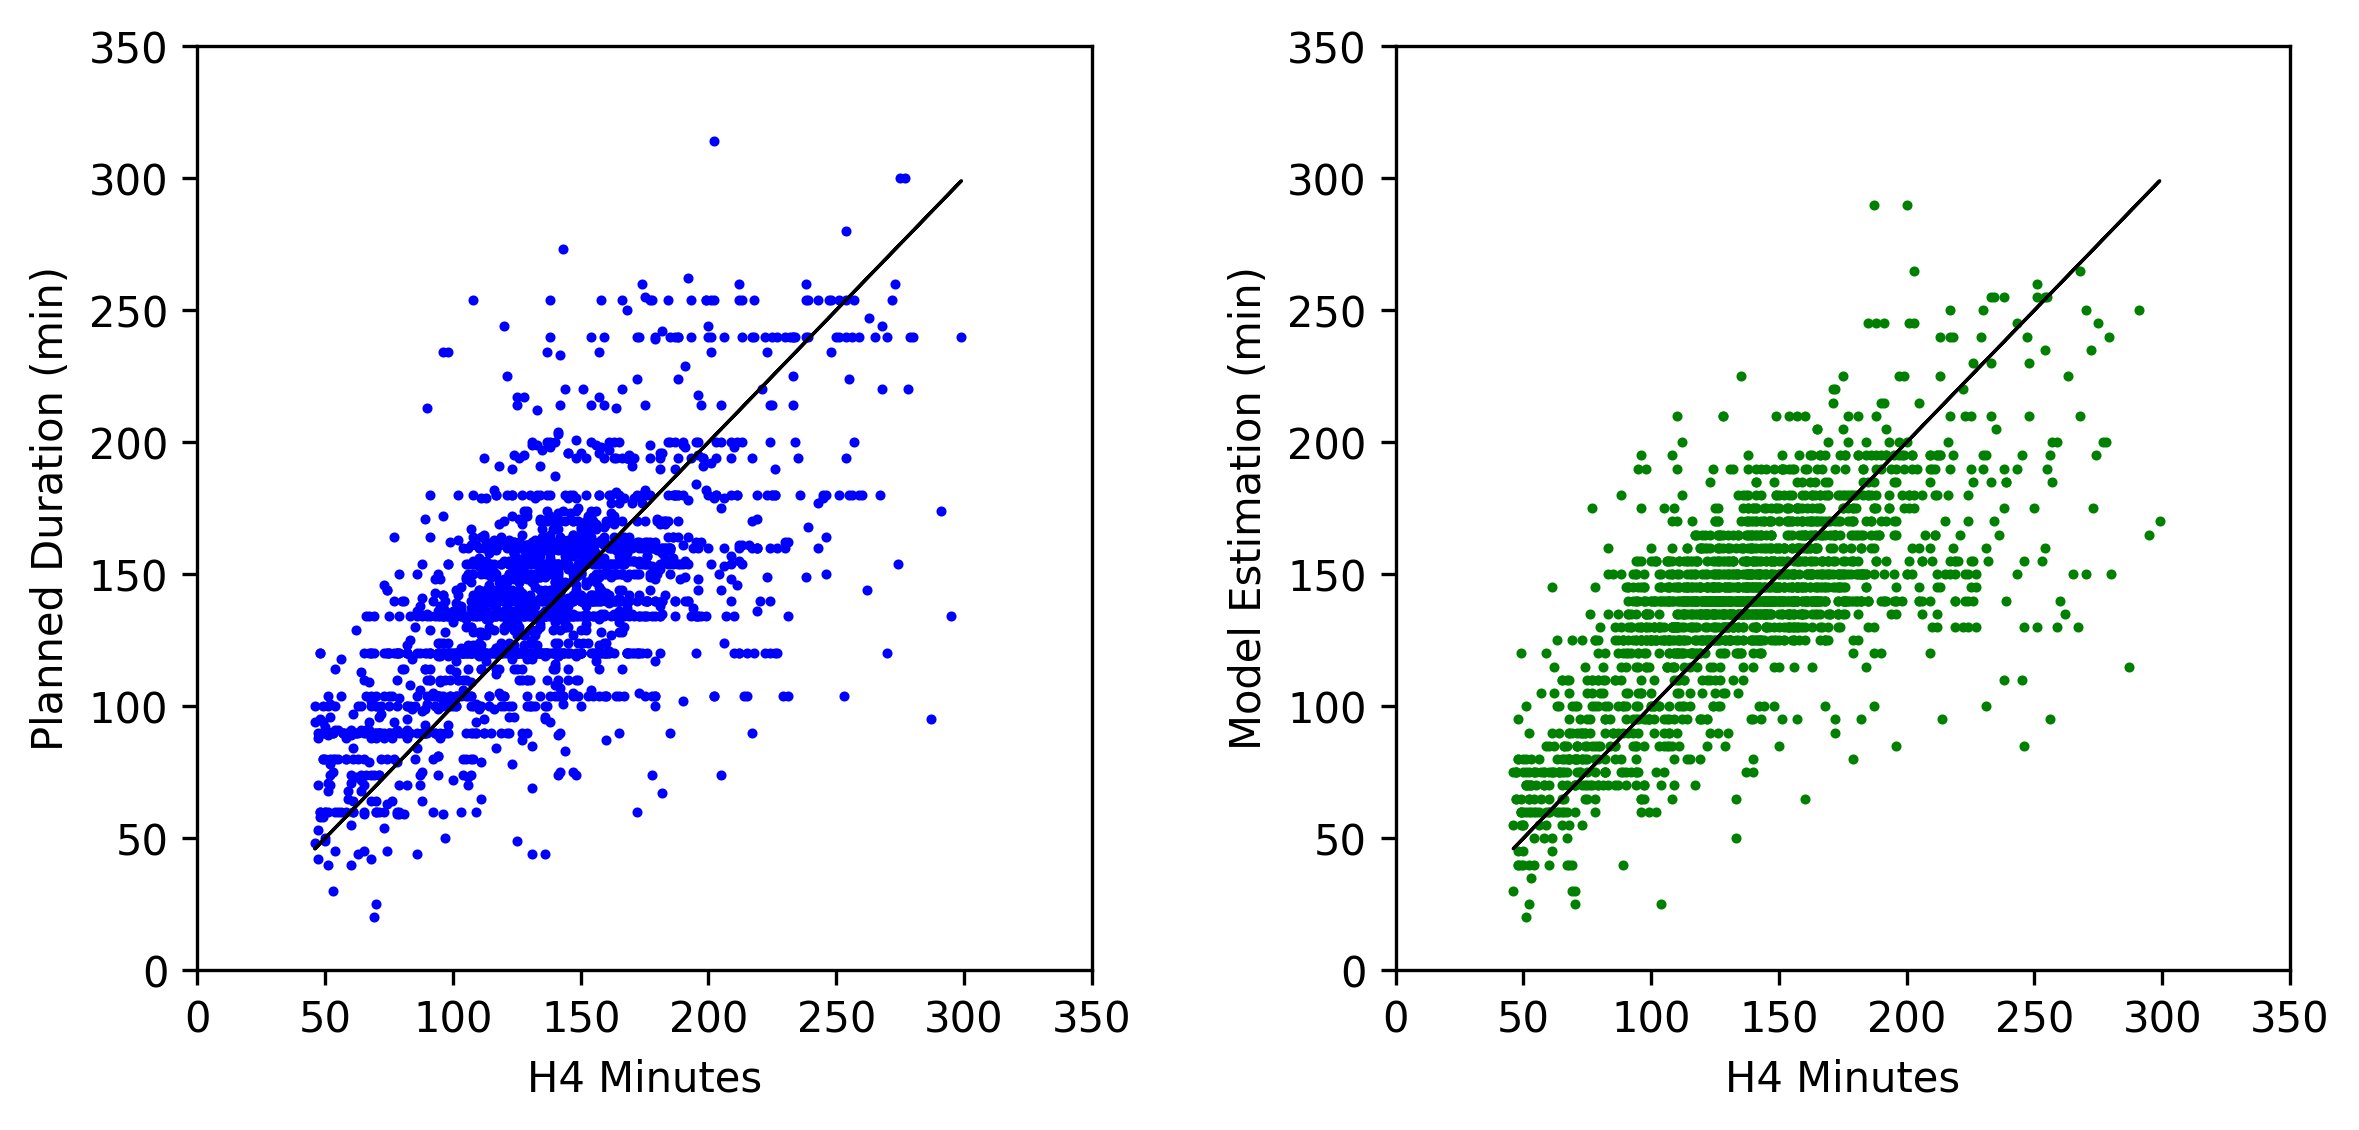

In [74]:
new_fig, axes = plt.subplots(1,2, figsize=(9, 4),  gridspec_kw={'wspace': 0.34}, dpi = 300)  
# Adjust the size as needed
#ax[0].plot()
axes[0].scatter(df_merged['H4 Minutes'],df_merged['Planned Duration'], label='Planned Duration', color='blue', s =2)
axes[0].plot(df_merged['H4 Minutes'],df_merged['H4 Minutes'], color='black', linewidth = 0.8)
#sns.lineplot(x= df_merged['H4 Minutes'], y= df_merged['H4 Minutes'], color='blue',ax = axes[0])
axes[0].set_xlim([0,350])
axes[0].set_ylim([0,350])
axes[0].set_xlabel('H4 Minutes')
axes[0].set_ylabel('Planned Duration (min)')

axes[1].scatter(df_merged['H4 Minutes'],df_merged['Model Estimation Time'], label='Model Estimated Duration', color='green', s = 2)
axes[1].plot(df_merged['H4 Minutes'],df_merged['H4 Minutes'], color='black', linewidth = 0.8)
#sns.lineplot(x= df_merged['H4 Minutes'], y= df_merged['H4 Minutes'], color='blue',ax = axes[0])
axes[1].set_xlim([0,350])
axes[1].set_ylim([0,350])
axes[1].set_xlabel('H4 Minutes')
axes[1].set_ylabel('Model Estimation (min)')
plt.show()


In [81]:
df_merged['Consultant RSE'] = (df_merged['Planned Duration']- 10-df_merged['H4 Minutes']) ** 2
df_merged['Model RSE'] = (df_merged['Model Estimation Time'] - df_merged['H4 Minutes']) ** 2

In [82]:
[np.sqrt(np.mean(df_merged['Consultant RSE'])), np.sqrt(np.mean(df_merged['Model RSE']))]

[36.24665173044707, 32.23904477406844]

In [83]:
# Calculate Percentage Error for each row
df_merged['Consultant % Error'] = np.abs((df_merged['Planned Duration'] -10- df_merged['H4 Minutes']) / df_merged['H4 Minutes']) * 100
df_merged['Model % Error'] = np.abs((df_merged['Model Estimation Time'] - df_merged['H4 Minutes']) / df_merged['H4 Minutes']) * 100

In [84]:
#len(df_merged)
[np.mean(df_merged['Consultant % Error']), np.mean(df_merged['Model % Error'])]

[20.318554544383076, 18.533626005523047]

In [85]:
[np.mean(df_merged['Consultant % Error']), np.mean(df_merged['Model % Error'])]

[20.318554544383076, 18.533626005523047]

### Comparative Plots

### Procedure wise comparision

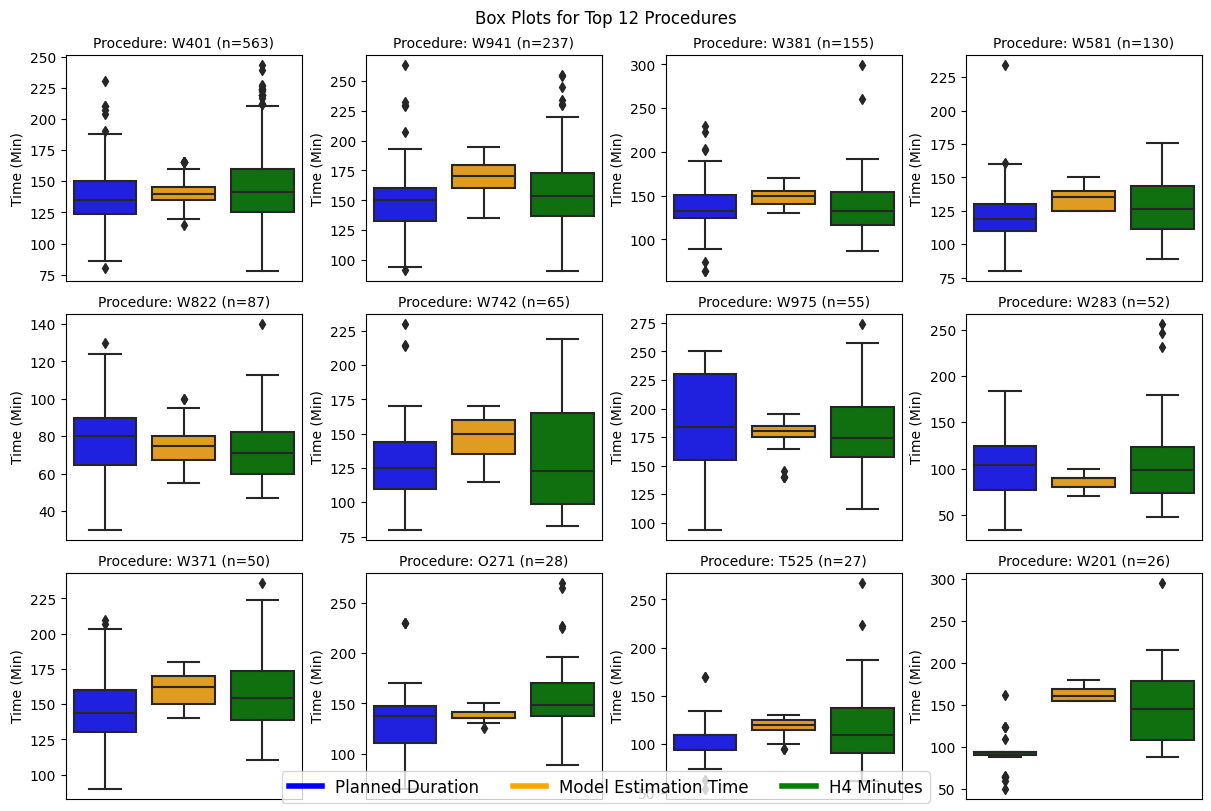

In [86]:
import seaborn as sns
import matplotlib.pyplot as plt

df_merged['Planned Duration']  = df_merged['Planned Duration'] - 10
# Identify top 15 procedures (based on frequency)
top_procedures = df_merged['Actual Procedure 1 Code 1'].value_counts().head(12).index

# Filter DataFrame for top procedures
df_top = df_merged[df_merged['Actual Procedure 1 Code 1'].isin(top_procedures)]

# Melt the DataFrame for easier plotting
df_melted = df_top.melt(
    id_vars=['Actual Procedure 1 Code 1'],
    value_vars=['Planned Duration', 'Model Estimation Time', 'H4 Minutes'],
    var_name='TimeType',
    value_name='Value'
)

# Set up the plot
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(12, 8), constrained_layout=True)
axes = axes.flatten()

palette = {'Planned Duration':'blue', 'Model Estimation Time':'orange', 'H4 Minutes':'green'}

# Plot box plots for each procedure
for i, procedure in enumerate(top_procedures):
    ax = axes[i]
    procedure_data = df_melted[df_melted['Actual Procedure 1 Code 1'] == procedure]
    sns.boxplot(
        data= procedure_data,
        x='TimeType',
        y='Value',
        ax=ax,
        palette=palette
    )
    
    ax.set_title(f'Procedure: {procedure} (n={int(len(procedure_data)/3)})', fontsize=10)
    ax.set_xlabel('')
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)  # Turn off x-ticks
    ax.set_ylabel('Time (Min)')

# Add a single legend to the first subplot
handles = [plt.Line2D([0], [0], color=color, lw=4) for color in palette.values()]
labels = palette.keys()
fig.legend(handles, palette.keys(), loc='lower center', ncol=3, title='', fontsize=12)


# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Box Plots for Top {len(top_procedures)} Procedures', fontsize=12)

plt.savefig(os.path.join(work_direc,'Benefit_analysis_oct25_feb26/Individaul Procedure wise performance.png'), dpi = 300)

plt.show()


In [87]:
# Identify top 15 procedures (based on frequency)
top_procedures = df_merged['Actual Procedure 1 Code 1'].value_counts().head(12).index

# Filter DataFrame for top procedures
df_top = df_merged[df_merged['Actual Procedure 1 Code 1'].isin(top_procedures)]

# Melt the DataFrame for easier plotting
rmse_array = np.zeros((len(top_procedures),2))
# Plot box plots for each procedure
for i, procedure in enumerate(top_procedures):
    #rmse_array[i,0] = procedure
    procedure_data = df_top[df_top['Actual Procedure 1 Code 1'] == procedure]
    rmse_array[i,0] = np.sqrt(np.mean((procedure_data['Planned Duration'] -10 - procedure_data['H4 Minutes']) ** 2))
    rmse_array[i,0] = round(rmse_array[i,0],2)
    rmse_array[i,1] = np.sqrt(np.mean((procedure_data['Model Estimation Time'] - procedure_data['H4 Minutes']) ** 2))
    rmse_array[i,1] = round(rmse_array[i,1],2)


In [88]:
pd.DataFrame(rmse_array, columns = ['Planned vs Real', 'Model est vs real'], index = top_procedures)

,Planned vs Real,Model est vs real
Actual Procedure 1 Code 1,,
W401,33.50,25.72
W941,36.39,28.52
W381,31.99,30.08
W581,32.67,21.34
W822,19.10,15.92
W742,35.99,30.99
W975,47.04,32.67
W283,46.84,48.19
W371,37.97,25.54


#### Scatter plot

In [89]:
df_merged_sorted_by_time_value = df_merged.sort_values(by = ['H4 Minutes']).reset_index(drop=True)
df_merged_sorted_by_time_value = df_merged_sorted_by_time_value[df_merged_sorted_by_time_value['H4 Minutes'] > 10]

In [90]:
#df_merged_sorted_by_time_value

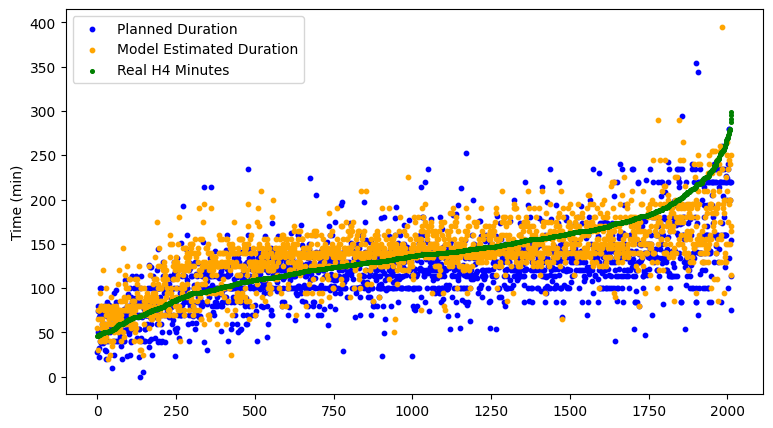

In [91]:
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.scatter(df_merged_sorted_by_time_value['Patient ID'].index,df_merged_sorted_by_time_value['Planned Duration']-10, label='Planned Duration', color='blue', s=10)
ax1.scatter(df_merged_sorted_by_time_value['Patient ID'].index, df_merged_sorted_by_time_value['Model Estimation Time'], label='Model Estimated Duration', color='orange', s = 10)
ax1.scatter(df_merged_sorted_by_time_value['Patient ID'].index, df_merged_sorted_by_time_value['H4 Minutes'], label='Real H4 Minutes', color='green', s = 7)

ax1.set_ylabel('Time (min)')
#ax1.set_xlabel('Patient ID')
ax1.legend(loc='upper left')

plt.savefig(os.path.join(work_direc,'Benefit_analysis_oct25_feb26/Case wise_time_estimation performance.png'), dpi = 300)

plt.show()

# Optimisation Benefit analysis

#### Sessions booking and patients related data

In [6]:
from procedure_time_and_variabiltiy_related_functions import load_timeslot_file
sessions_plan = load_timeslot_file( os.path.join(work_direc,'Benefit_analysis_oct25_feb26/ESEOC_Sessions_futuristic.xlsx'))

#tidying consultant code related data
sessions_plan['Consultant Code'] = sessions_plan['Consultant Code'].apply(lambda x: 'C9999999' if pd.isna(x) or '9999' in x else x)
sessions_plan['Consultant Code'] = sessions_plan.apply(
    lambda row: 'C' + re.sub(r'[^a-zA-Z]', '', row['Consultant']).lower()[0:7] 
    if row['Consultant Code'] == 'Unknown' and row['Consultant'] != '*Unspecified' 
    else row['Consultant Code'], 
    axis=1
)

In [7]:
sessions_plan.shape

(746, 15)

In [8]:
sessions_plan['Session Planned Start Date/Time'] = pd.to_datetime(sessions_plan['Session Planned Start Date/Time'])
# Filter out consultants with fewer than 5 appearances
counts = sessions_plan.groupby('Consultant Code')['Consultant Code'].transform('count')
sessions_filtered = sessions_plan[(counts >= 5) & (sessions_plan['Consultant Code'] !='Unknown')].copy()

# Sort by Consultant and then by Time (Oldest to Newest)
sessions_filtered = sessions_filtered.sort_values(['Consultant Code', 'Session Planned Start Date/Time'])

# Keep the oldest 80% per consultant
# We use groupby + head with a dynamic calculation
sessions_filtered = (
    sessions_filtered.groupby('Consultant Code', group_keys=False)
    .apply(lambda x: x.head(int(len(x) * 0.85)))
)

In [9]:
sessions_filtered.shape

(574, 15)

In [51]:
patient_df = pd.read_excel(os.path.join(work_direc,'Benefit_analysis_oct25_feb26/ESEOC_cases_oct25_feb26_futuristic.xlsx'))

#
patient_df['Consultant Code'] = patient_df['Consultant Code'].apply(lambda x: 'C9999999' if pd.isna(x) or '9999' in x else x)

patient_df['Consultant Code'] = patient_df.apply(
    lambda row: 'C' + re.sub(r'[^a-zA-Z]', '', row['Consultant']).lower()[0:7] 
    if row['Consultant Code'] == 'Unknown' and row['Consultant'] != '*Unspecified' 
    else row['Consultant Code'], 
    axis=1
)

print(patient_df.shape)
# Step 1: Count duplicates
dup_counts = patient_df.groupby('Patient ID').cumcount().add(1)

# Step 2: Convert ID to string
patient_df['Patient ID'] = patient_df['Patient ID'].astype(str)

# Step 3: Add suffix only where there are duplicates
patient_df['Patient ID'] = patient_df.apply(lambda row: f"{row['Patient ID']}_{dup_counts[row.name]}"
                    if (patient_df['Patient ID'] == row['Patient ID']).sum() > 1
                    else row['Patient ID'], axis=1)

(2351, 9)


In [52]:
patient_df.shape

(2351, 9)

In [13]:
#Balancing sessions count per consultant for patients counts to avoid underbooking
for consultant in sessions_filtered['Consultant Code'].unique():
    #for consultant in ['C4677242','C4521035']:
    print(f'\n Consultant {consultant}')
    consultant_sess = sessions_filtered[sessions_filtered['Consultant Code'] == consultant].copy()
    print([consultant_sess.shape[0],
           patient_df[patient_df['Consultant Code'] == consultant].shape[0]])
    consultant_sess = consultant_sess.sort_values(['Session Planned Start Date/Time'])

    removed_sessions = []
    
    while consultant_sess['Remaining Slot Minutes'].sum() /180 >patient_df[patient_df['Consultant Code'] == consultant].shape[0]:
        removed_sessions.extend(consultant_sess[int(consultant_sess.shape[0] * 0.8):]['Session ID'].tolist())
        consultant_sess = consultant_sess.head(int(consultant_sess.shape[0] * 0.8))
        print(removed_sessions)

    sessions_filtered = sessions_filtered[~sessions_filtered['Session ID'].isin(removed_sessions)]


 Consultant C2983125
[17, 84]

 Consultant C3296400
[13, 37]
['20260108|SVC-250|2398|815|0', '20260115|SVC-250|2398|815|0', '20260122|SVC-250|2398|815|0']

 Consultant C3320752
[17, 91]

 Consultant C3326404
[11, 27]
['20260115|SVC-250|2585|815|0', '20260122|SVC-250|2585|815|0', '20260205|SVC-250|2585|815|0']

 Consultant C3352315
[9, 34]

 Consultant C3589917
[12, 49]

 Consultant C3658987
[10, 34]

 Consultant C4027799
[11, 33]

 Consultant C4031831
[14, 46]

 Consultant C4047872
[12, 47]

 Consultant C4089607
[12, 56]

 Consultant C4371852
[7, 24]

 Consultant C4434142
[8, 26]

 Consultant C4521035
[12, 32]
['20260128|SVC-250|2838|815|0', '20260129|SVC-250|3429|815|0', '20260205|SVC-250|3429|815|0']

 Consultant C4526360
[17, 66]

 Consultant C4537935
[15, 66]

 Consultant C4625805
[18, 84]

 Consultant C4641678
[14, 54]

 Consultant C4677242
[17, 61]

 Consultant C4684796
[5, 14]
['20260130|SVC-250|5209|815|0']

 Consultant C4690524
[12, 46]

 Consultant C4726342
[13, 63]

 Consul

In [14]:
[sessions_plan.shape, sessions_filtered.shape, patient_df.shape]

[(746, 15), (557, 15), (2351, 9)]

In [15]:
sessions_filtered['Consultant Code'].unique()

array(['C2983125', 'C3296400', 'C3320752', 'C3326404', 'C3352315',
       'C3589917', 'C3658987', 'C4027799', 'C4031831', 'C4047872',
       'C4089607', 'C4371852', 'C4434142', 'C4521035', 'C4526360',
       'C4537935', 'C4625805', 'C4641678', 'C4677242', 'C4684796',
       'C4690524', 'C4726342', 'C4752583', 'C5206961', 'C6025167',
       'C6034317', 'C6044717', 'C6057944', 'C6074474', 'C6075125',
       'C6077137', 'C6128154', 'C6135761', 'C6141709', 'C6163962',
       'C7012778', 'C7037572', 'C7045877', 'C7083827', 'C7088168',
       'C7155831', 'C7177363', 'C7293735', 'C7590715', 'Calnajja',
       'Cjafarah', 'Ckheradm', 'Cmulavis', 'Cnabulya', 'Cravalpr'],
      dtype=object)

In [16]:
patient_df = patient_df[patient_df['Consultant Code'].isin(sessions_filtered['Consultant Code'])]
patient_df.shape

(2189, 9)

In [17]:
sessions_filtered['Total Slot Minutes'].sum()

284940.0

In [19]:
#[cons for cons in surgery_consultants if cons not in sessions_consultants]
[cons for cons in sessions_filtered['Consultant Code'].tolist() if cons not in patient_df['Consultant Code'].tolist()]

[]

### Real Timeline

In [121]:
real_timeline = pd.read_excel(os.path.join(work_direc,'Benefit_analysis_oct25_feb26/ESEOC_cases_oct25_feb26.xlsx'))

real_timeline.loc[:,'Case End Date/Time'] = pd.to_datetime(real_timeline['Case End Date/Time'])
real_timeline['Patient ID'] = real_timeline['Patient ID'].astype(str)

session_real = load_timeslot_file(os.path.join(work_direc,'Benefit_analysis_oct25_feb26/ESEOC_Sessions.xlsx'))
#tidying consultant code related data
session_real['Consultant Code'] = session_real['Consultant Code'].apply(lambda x: 'C9999999' if pd.isna(x) or '9999' in x else x)
session_real['Consultant Code'] = session_real.apply(
    lambda row: 'C' + re.sub(r'[^a-zA-Z]', '', row['Consultant']).lower()[0:7] 
    if row['Consultant Code'] == 'Unknown' and row['Consultant'] != '*Unspecified' 
    else row['Consultant Code'], 
    axis=1
)

In [122]:
real_timeline = real_timeline.merge(sessions_plan[['Session ID','Total Slot Minutes', 'Session Planned End Date/Time']].rename(columns={'Total Slot Minutes':'Session Time limit'}), on ='Session ID', how = 'left')

In [123]:
# Step 1: Max cumsum per session
session_max =real_timeline.groupby('Session ID')['Case End Date/Time'].max().reset_index()

# Step 2: Merge with max_time_limit from df2
#session_usage = session_max.merge(sessions_plan[['Session ID','Session Planned End Date/Time']], on='Session ID')
session_usage = session_max.merge(session_real, on='Session ID', how = 'inner')

session_usage = session_usage[session_usage['Session ID'].isin(sessions_filtered['Session ID'])]

In [124]:
#session_real.shape

In [125]:
[real_timeline[real_timeline['Session ID'].isin(session_usage['Session ID'])]['H4 Minutes'].sum(), session_usage["Total Slot Minutes"].sum(), real_timeline[real_timeline['Session ID'].isin(session_usage['Session ID'])]['H4 Minutes'].sum()/(session_usage["Total Slot Minutes"].sum())]

[220523.0, 283275.0, 0.7784767452122496]

In [126]:
[sessions_filtered.shape, session_usage.shape, real_timeline[real_timeline['Session ID'].isin(session_usage['Session ID'])].shape]

[(554, 15), (554, 19), (1727, 37)]

##### Overruned by 30 minutes

In [127]:
[session_usage[session_usage['Case End Date/Time']> session_usage['Session Planned End Date/Time'] + pd.Timedelta(minutes = 30)].shape,
 session_usage[session_usage['Case End Date/Time']> session_usage['Session Planned End Date/Time'] + pd.Timedelta(minutes = 30)].shape[0]/session_usage.shape[0]
]

[(54, 19), 0.09747292418772563]

##### Possible cancellations

In [128]:
[session_usage[session_usage['Case End Date/Time']> session_usage['Session Planned End Date/Time'] + pd.Timedelta(minutes = 60)].shape,
 session_usage[session_usage['Case End Date/Time']> session_usage['Session Planned End Date/Time'] + pd.Timedelta(minutes = 60)].shape[0]/session_usage.shape[0]
]

[(16, 19), 0.02888086642599278]

##### Underrunning

In [129]:
[
session_usage[session_usage['Session Planned End Date/Time'] > session_usage['Case End Date/Time'] + pd.Timedelta(minutes = 60)
]['Session ID'].nunique(),
session_usage[session_usage['Session Planned End Date/Time'] > session_usage['Case End Date/Time'] + pd.Timedelta(minutes = 60)
].shape[0]/session_usage.shape[0]
]

[209, 0.37725631768953066]

In [130]:
[session_usage[session_usage['Session Planned End Date/Time'] > session_usage['Case End Date/Time'] + pd.Timedelta(minutes = 30)
]['Session ID'].nunique(),
session_usage[session_usage['Session Planned End Date/Time'] > session_usage['Case End Date/Time'] + pd.Timedelta(minutes = 30)
].shape[0]/session_usage.shape[0]
]

[316, 0.5703971119133574]

In [132]:
# Step 3: Filter overrun sessions
session_usage[
    session_usage['Session Planned End Date/Time'] < session_usage['Case End Date/Time'] - pd.Timedelta(minutes = 60)
]['Session ID'].nunique()


16

In [133]:
real_timeline[real_timeline['Session ID'].isin(session_usage['Session ID'])].shape

(1727, 37)

### Scheduling Model- Initiating and data loading

In [32]:
from Scheduling_Model import Scheduling_Model

In [94]:
sessions_filtered = sessions_filtered[sessions_filtered['Session ID'].isin(session_usage['Session ID'])].copy()
patient_df = patient_df[patient_df['Consultant Code'].isin(sessions_filtered['Consultant Code'])].copy()

In [95]:
sched_model = Scheduling_Model(patient_df, sessions_filtered)

In [96]:
[sessions_filtered.shape[0], patient_df.shape[0]]

[554, 2189]

### 1st objective only

In [97]:
from procedure_time_and_variabiltiy_related_functions import get_prediction_required_parameters

In [98]:
procedure_time_prediction_parameters = get_prediction_required_parameters(work_direc, trained_models_direc)

In [99]:

sched_model.session_max_util = 0.92 # (default 0.9)
sched_model.theatre_prpn_min =  7.5 # (default 7.5)
#sched_model.theatre_prep_min =  5

schedule_updated_SCIP = pd.DataFrame()

sessions_updated_SCIP = pd.DataFrame()

unbooked_patients = patient_df.copy()

obj_weightage =  {'objective1':1}

#considered_consultants = []

#Balancing sessions count per consultant for patients counts to avoid underbooking
for consultant in sessions_filtered['Consultant Code'].unique():
    #for consultant in ['C4677242','C4521035']:
    print(f'\n Consultant {consultant}')
    
    consultant_sess = sessions_filtered[sessions_filtered['Consultant Code'] == consultant].copy()
    
    prioritise_patients = unbooked_patients[unbooked_patients['Consultant Code'] == consultant]

    sessions_booked = 0

    sched_model.CASES = tuple(prioritise_patients["Patient ID"])
    sched_model.SESSIONS = tuple(consultant_sess["Session ID"])
    sched_model.SESSION_DURATION = pd.Series(consultant_sess["Total Slot Minutes"].values, index=consultant_sess["Session ID"]).to_dict()
    sched_model.SUM_ALL_SESSIONS_DURATION = sum(consultant_sess["Total Slot Minutes"])
    sched_model.TASKS = tuple(product(prioritise_patients['Patient ID'], consultant_sess['Session ID']))
    sched_model.patients_df =prioritise_patients.copy().set_index('Patient ID', drop=False)
    sched_model.TASKS_ASSIGNED = {}
    sched_model.generate_tasks_durations(prioritise_patients, consultant_sess, None, procedure_time_prediction_parameters)
    
    hyper_param_SCIP = {'time limit': len(prioritise_patients)*len(consultant_sess)/20}

    #optimisation_algorithm = 'MIP Solver'
    
    sched_model.create_schedule_with_optimisation(optimisation_algorithm = 'MIP Solver', objectives = ('objective1',), 
                                      weightage= obj_weightage,
                                        hyper_param= hyper_param_SCIP)
    new_schedule = sched_model.schedule_new.copy()

    print(f'From selected {len(prioritise_patients)} patients {len(new_schedule)} are booked')

    schedule_updated_SCIP = pd.concat([schedule_updated_SCIP, new_schedule], axis = 0)

    unbooked_patients = unbooked_patients[~unbooked_patients['Patient ID'].isin(new_schedule['Patient ID'])].copy()

    sessions_updated_SCIP = pd.concat([sessions_updated_SCIP, sched_model.sessions_updated.copy()], axis = 0)

    print(f'{len(schedule_updated_SCIP)} patients are booked in total {len(sessions_updated_SCIP)} sessions')

    #sessions_booked+= len(consultant_sess)

    #considered_consultants.append(consultant)


 Consultant C2983125
Node 1, Objective Value 0.919, Time Elapsed 1.0
Node 3, Objective Value 0.919, Time Elapsed 1.0
Node 5, Objective Value 0.919, Time Elapsed 1.0
Node 7, Objective Value 0.919, Time Elapsed 1.0
Node 9, Objective Value 0.919, Time Elapsed 1.0
Node 11, Objective Value 0.919, Time Elapsed 1.0
Node 13, Objective Value 0.919, Time Elapsed 1.0
Node 15, Objective Value 0.919, Time Elapsed 1.0
Node 17, Objective Value 0.919, Time Elapsed 1.0
Node 19, Objective Value 0.919, Time Elapsed 1.0
Node 21, Objective Value 0.919, Time Elapsed 1.0
Node 23, Objective Value 0.919, Time Elapsed 1.0
Node 25, Objective Value 0.919, Time Elapsed 1.0
Node 27, Objective Value 0.919, Time Elapsed 1.0
Node 29, Objective Value 0.919, Time Elapsed 1.0
Node 31, Objective Value 0.919, Time Elapsed 1.0
Node 14, Objective Value 0.919, Time Elapsed 1.0
Node 35, Objective Value 0.919, Time Elapsed 1.0
Node 37, Objective Value 0.919, Time Elapsed 1.0
Node 39, Objective Value 0.919, Time Elapsed 1.0
Nod

In [100]:
schedule_updated_SCIP['Planned H4 Minutes'].sum()/sessions_filtered["Total Slot Minutes"].sum()

0.8795516724031418

In [102]:
sessions_updated_SCIP[sessions_updated_SCIP['Session Utilisation']<0.5].shape

(3, 7)

In [103]:
[schedule_updated_SCIP.shape[0], session_real[session_real['Session ID'].isin(sessions_filtered['Session ID'])]['Total Cases'].sum()]

[1900, 1730]

In [104]:
[real_timeline[real_timeline['Patient ID'].astype(str).isin(schedule_updated_SCIP['Patient ID'].astype(str).tolist())]['Planned Duration'].sum(), sessions_filtered["Total Slot Minutes"].sum(), schedule_updated_SCIP['Planned H4 Minutes'].sum()]

[249718, 283275.0, 249155.0]

#### Reality Checking
Checking if the virtual schedule generated would have overrunning sessions or not, by making comparison with real-data

#### H4 Minutes and Utilisation (possible)

In [40]:
[real_timeline[real_timeline['Patient ID'].astype(str).isin(schedule_updated_SCIP['Patient ID'].astype(str).tolist())]['H4 Minutes'].sum(), real_timeline[real_timeline['Patient ID'].astype(str).isin(schedule_updated_SCIP['Patient ID'].astype(str).tolist())]['H4 Minutes'].sum()/sessions_filtered["Total Slot Minutes"].sum()]

[242191.0, 0.8499719239138064]

In [120]:
242191-220523

21668

In [ ]:
#real_timeline[real_timeline['Patient ID'].astype(str).isin(schedule_updated_SCIP['Patient ID'].astype(str).tolist())]['H4 Minutes'].sum() - session_usage['Total H4 Minutes'].sum()

In [109]:
planned_nd_real = pd.merge(schedule_updated_SCIP, real_timeline[['Patient ID', 'H4 Minutes']], on = ['Patient ID'], how = 'left')
planned_nd_real.shape

(1900, 9)

In [110]:
planned_nd_real['Session Cumulative'] = planned_nd_real.groupby('Session ID')['H4 Minutes'].cumsum() + (planned_nd_real.groupby('Session ID').cumcount() +1)*9

planned_nd_real = planned_nd_real.merge(sessions_filtered[['Session ID','Total Slot Minutes']].rename(columns={'Total Slot Minutes':'Session Time limit'}), on ='Session ID', how = 'left')

##### Overruned by 30 minutes

In [111]:
[planned_nd_real[planned_nd_real['Session Cumulative'] > planned_nd_real['Session Time limit']+30]['Session ID'].nunique(), 
 planned_nd_real[planned_nd_real['Session Cumulative'] > planned_nd_real['Session Time limit']+30]['Session ID'].nunique()/len(sessions_filtered)
]

[86, 0.1552346570397112]

##### Possible cancellations

In [112]:
[planned_nd_real[planned_nd_real['Session Cumulative'] > planned_nd_real['Session Time limit']+60]['Session ID'].nunique(),
 planned_nd_real[planned_nd_real['Session Cumulative'] > planned_nd_real['Session Time limit']+60]['Session ID'].nunique()/len(sessions_filtered)
]

[53, 0.09566787003610108]

##### Underrunning

In [114]:
# Step 1: Max cumsum per session
session_max = planned_nd_real.groupby('Session ID')['Session Cumulative'].max().reset_index(name='max_cumsum')

# Step 2: Merge with max_time_limit from df2
session_usage = session_max.merge(sessions_filtered[['Session ID','Total Slot Minutes']].rename(columns={'Total Slot Minutes':'Session Time limit'}), on='Session ID')

#len(planned_nd_real.groupby('Session ID')['Session Cumulative'].max() < planned_nd_real.groupby('Session ID')['Session Time limit']-60])

In [115]:
# Step 3: Filter underutilized sessions
[session_usage[session_usage['max_cumsum'] < session_usage['Session Time limit'] - 30
]['Session ID'].nunique(),
 session_usage[session_usage['max_cumsum'] < session_usage['Session Time limit'] - 30
]['Session ID'].nunique()/len(session_usage)
]

[346, 0.6245487364620939]

In [116]:
[session_usage[session_usage['max_cumsum'] < session_usage['Session Time limit'] - 60
]['Session ID'].nunique(),
 session_usage[session_usage['max_cumsum'] < session_usage['Session Time limit'] - 60
]['Session ID'].nunique()/len(session_usage)
]

[244, 0.4404332129963899]

#### Overrning-other approach

In [117]:
overutilized_sessions = session_usage[
    session_usage['max_cumsum'] > session_usage['Session Time limit'] + 60
]['Session ID']

In [118]:
overutilized_sessions.nunique()

53